In [1]:
from langgraph.graph import StateGraph, START, END, MessagesState
from langchain_ollama import ChatOllama
import sqlite3
from langgraph.checkpoint.sqlite import SqliteSaver

/home/pinaka-linux/langchain/venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
llm = ChatOllama(model="llama3")
def chat_node(state: MessagesState) -> MessagesState:
    response = llm.invoke(state["messages"])
    return {"messages": [response.content]}

In [3]:
builder = StateGraph(MessagesState)
builder.add_node("chat", chat_node)
builder.add_edge(START, "chat")
builder.add_edge("chat", END)


In [4]:
connection = sqlite3.connect("memory.db", check_same_thread=False)
checkpointer = SqliteSaver(connection)
model = builder.compile(checkpointer=checkpointer)

In [6]:
CONFIG = {
    'configurable' : {'thread_id': 'thread_check'}
}
query = {'messages': [{"role": "user", "content": "hello, my name is John."}]}

In [18]:
res = model.invoke(query, config=CONFIG)
res

{'messages': [HumanMessage(content='hello, my name is John.', additional_kwargs={}, response_metadata={}, id='a9477039-51da-4c8e-8a15-ad058b71e0b8'),
  HumanMessage(content="Nice to meet you, John! I'm your friendly AI assistant. What brings you here today? Do you have a specific question or topic you'd like to discuss? I'm all ears (or rather, all text)!", additional_kwargs={}, response_metadata={}, id='8f1fe102-48e5-41d3-ab5b-40f465c2f78a'),
  HumanMessage(content='hello, my name is John.', additional_kwargs={}, response_metadata={}, id='11841055-60ee-4604-83ae-87bc69b4b6ac'),
  HumanMessage(content="A classic introduction, and welcome again! It's great to meet you too, John! Since we're already having a chat, I'll assume it's okay if we just have a casual conversation. No specific question or topic in mind? That's perfectly fine! We can just explore some ideas, share some thoughts, or even play a game together (if you'd like). What do you say, John?", additional_kwargs={}, response_

In [7]:
db_state = model.get_state(CONFIG)
db_state.values['messages'][-1]

HumanMessage(content="A classic introduction, and welcome again! It's great to meet you too, John! Since we're already having a chat, I'll assume it's okay if we just have a casual conversation. No specific question or topic in mind? That's perfectly fine! We can just explore some ideas, share some thoughts, or even play a game together (if you'd like). What do you say, John?", additional_kwargs={}, response_metadata={}, id='90679249-fedb-41a9-a47e-21917d5ca7c5')

In [25]:
CONFIG1 = {
    'configurable' : {'thread_id': 'thread_check1'}
}
state = model.get_state(CONFIG1)
state

StateSnapshot(values={}, next=(), config={'configurable': {'thread_id': 'thread_check1'}}, metadata=None, created_at=None, parent_config=None, tasks=(), interrupts=())

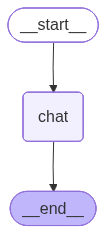

In [ ]:
from IPython.display import Image
Image(model.get_graph().draw_mermaid_png())

In [ ]:
prompt = {'messages': [{"role": "user", "content": "Hi, my name is john."}]}
final_state = model.invoke(prompt)
final_state

{'messages': [HumanMessage(content='Hi, my name is john.', additional_kwargs={}, response_metadata={}, id='4a2d01d9-987a-4d75-bfb0-2acfc4f55529'),
  HumanMessage(content="Nice to meet you, John! I'm happy to chat with you. What's on your mind today? Do you have a specific topic you'd like to discuss or just looking for some casual conversation?", additional_kwargs={}, response_metadata={}, id='2ac4d8e7-a8b3-4924-81da-0e48899e6ade')]}

In [ ]:
prompt = {'messages': [{"role": "user", "content": "What is my name?"}]}
final_state = model.invoke(prompt)
final_state

{'messages': [HumanMessage(content='What is my name?', additional_kwargs={}, response_metadata={}, id='d875111a-a10f-473d-abaa-a6acf4776ab6'),
  HumanMessage(content="I'm happy to help! However, I don't know your name. As a conversational AI, I don't have personal knowledge about you or any other individual. Each time you interact with me, it's like starting from scratch. So, what would you like to be called today?", additional_kwargs={}, response_metadata={}, id='5aa56bd0-d4b4-4f5f-a98f-30fe8b8a6ece')]}